## EDA - bureau.csv

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns',None)
pd.set_option('display.max_row',None)

In [9]:
df0 = pd.read_csv(r"C:\Users\meet.gajera\OneDrive\Desktop\hcdr__\Data\row\bureau.csv")

In [10]:
df0.head()

,SK_ID_CURR,SK_ID_BUREAU,CREDIT_ACTIVE,CREDIT_CURRENCY,DAYS_CREDIT,CREDIT_DAY_OVERDUE,DAYS_CREDIT_ENDDATE,DAYS_ENDDATE_FACT,AMT_CREDIT_MAX_OVERDUE,CNT_CREDIT_PROLONG,AMT_CREDIT_SUM,AMT_CREDIT_SUM_DEBT,AMT_CREDIT_SUM_LIMIT,AMT_CREDIT_SUM_OVERDUE,CREDIT_TYPE,DAYS_CREDIT_UPDATE,AMT_ANNUITY
0,215354,5714462,Closed,currency 1,-497,0,-153.0,-153.0,NaN,0,91323.0,0.0,NaN,0.0,Consumer credit,-131,NaN
1,215354,5714463,Active,currency 1,-208,0,1075.0,NaN,NaN,0,225000.0,171342.0,NaN,0.0,Credit card,-20,NaN
2,215354,5714464,Active,currency 1,-203,0,528.0,NaN,NaN,0,464323.5,NaN,NaN,0.0,Consumer credit,-16,NaN
3,215354,5714465,Active,currency 1,-203,0,NaN,NaN,NaN,0,90000.0,NaN,NaN,0.0,Credit card,-16,NaN
4,215354,5714466,Active,currency 1,-629,0,1197.0,NaN,77674.5,0,2700000.0,NaN,NaN,0.0,Consumer credit,-21,NaN


In [11]:
df0.columns

Index(['SK_ID_CURR', 'SK_ID_BUREAU', 'CREDIT_ACTIVE', 'CREDIT_CURRENCY',
       'DAYS_CREDIT', 'CREDIT_DAY_OVERDUE', 'DAYS_CREDIT_ENDDATE',
       'DAYS_ENDDATE_FACT', 'AMT_CREDIT_MAX_OVERDUE', 'CNT_CREDIT_PROLONG',
       'AMT_CREDIT_SUM', 'AMT_CREDIT_SUM_DEBT', 'AMT_CREDIT_SUM_LIMIT',
       'AMT_CREDIT_SUM_OVERDUE', 'CREDIT_TYPE', 'DAYS_CREDIT_UPDATE',
       'AMT_ANNUITY'],
      dtype='object')

In [12]:
df = df0.copy()

In [13]:
df = df[['SK_ID_CURR',
           'CREDIT_ACTIVE',
           'DAYS_CREDIT',
           'AMT_CREDIT_SUM',
           'AMT_CREDIT_SUM_DEBT',
           'AMT_CREDIT_SUM_LIMIT',
           'AMT_ANNUITY']].copy()

In [14]:
df.head()

,SK_ID_CURR,CREDIT_ACTIVE,DAYS_CREDIT,AMT_CREDIT_SUM,AMT_CREDIT_SUM_DEBT,AMT_CREDIT_SUM_LIMIT,AMT_ANNUITY
0,215354,Closed,-497,91323.0,0.0,NaN,NaN
1,215354,Active,-208,225000.0,171342.0,NaN,NaN
2,215354,Active,-203,464323.5,NaN,NaN,NaN
3,215354,Active,-203,90000.0,NaN,NaN,NaN
4,215354,Active,-629,2700000.0,NaN,NaN,NaN


In [15]:
df.shape

(1716428, 7)

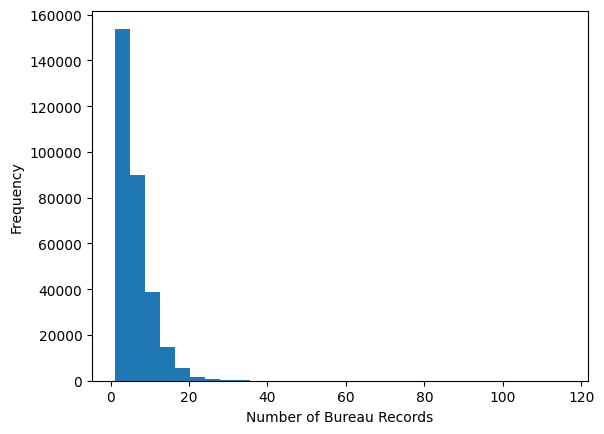

In [16]:
df0.groupby('SK_ID_CURR').size().plot(kind='hist', bins=30)
plt.xlabel('Number of Bureau Records')
plt.show()

In [17]:
df['CREDIT_ACTIVE'].isnull().sum()

0

In [18]:
df['CREDIT_ACTIVE'].value_counts()

CREDIT_ACTIVE
Closed      1079273
Active       630607
Sold           6527
Bad debt         21
Name: count, dtype: int64

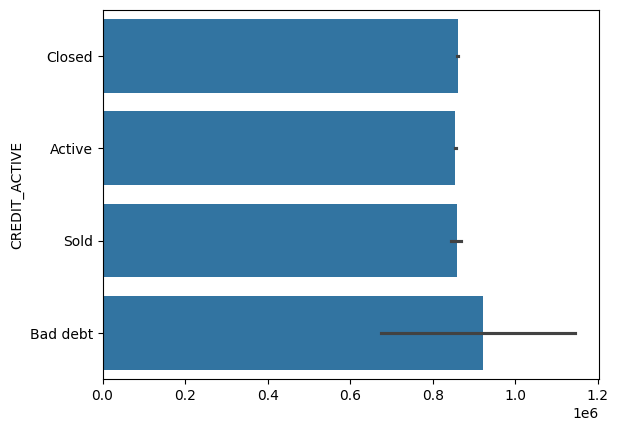

In [19]:
sns.barplot(df['CREDIT_ACTIVE'])
plt.show()

In [20]:
df['DAYS_CREDIT'].isnull().sum()

0

In [21]:
df['YEARS_SINCE_CREDIT'] = abs(df['DAYS_CREDIT'])/365

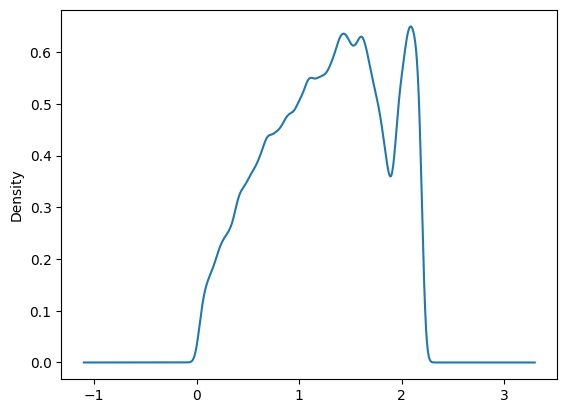

In [22]:
np.log1p(df['YEARS_SINCE_CREDIT']).plot(kind='kde')
plt.show()

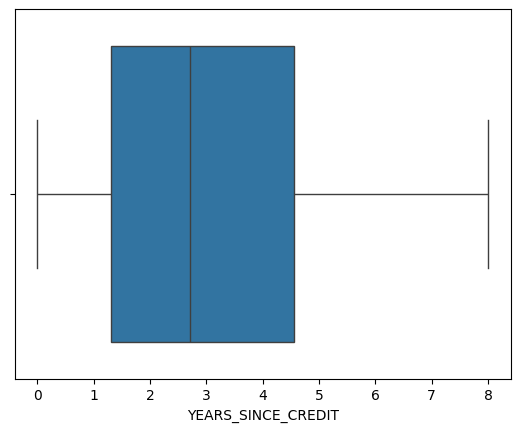

In [23]:
sns.boxplot(x=df['YEARS_SINCE_CREDIT'])
plt.show()

In [24]:
df['AMT_CREDIT_SUM'].isnull().sum()

13

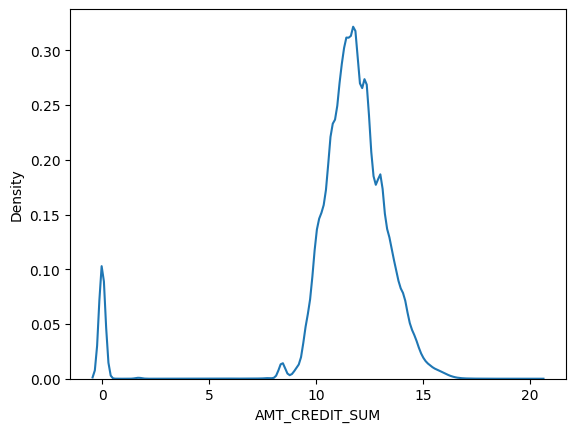

In [25]:
sns.kdeplot(np.log1p(df['AMT_CREDIT_SUM']))
plt.show()

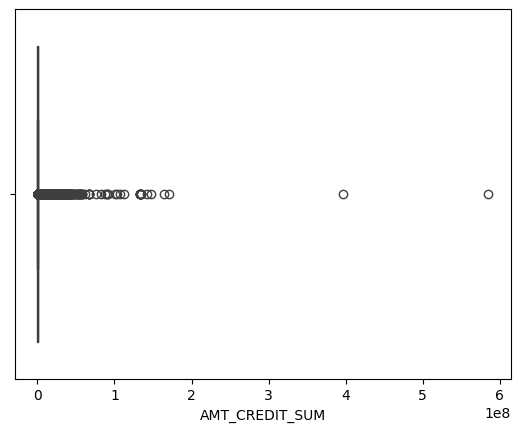

In [26]:
sns.boxplot(x=df['AMT_CREDIT_SUM'])
plt.show()

In [27]:
df['AMT_CREDIT_SUM_DEBT'].isnull().sum()

257669

- 15% missing values

In [28]:
(df['AMT_CREDIT_SUM_DEBT'] < 0).sum()

8418

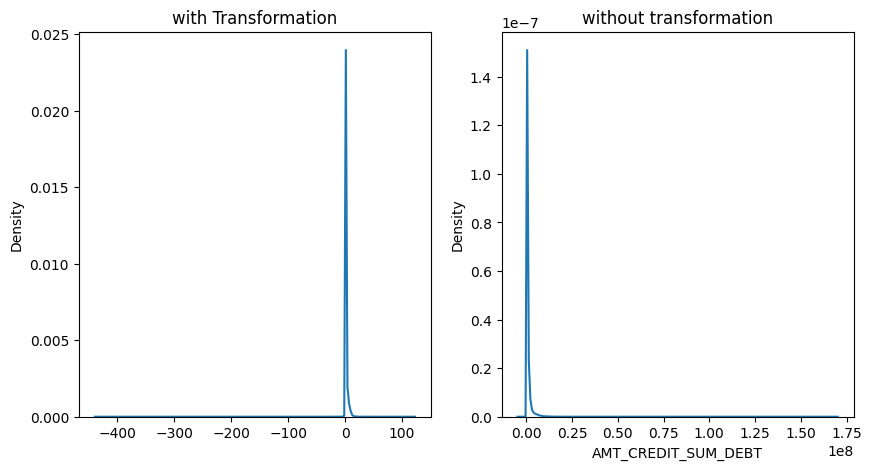

skewness(before):  36.4145383444218
skewness(after):  -94.5882927833509


In [29]:
from sklearn.preprocessing import PowerTransformer
pe = PowerTransformer(method='yeo-johnson')
trans = pe.fit_transform(df[['AMT_CREDIT_SUM_DEBT']])

plt.figure(figsize=(10,5))

plt.subplot(121)
sns.kdeplot(trans.ravel())
plt.title("with Transformation")

plt.subplot(122)
sns.kdeplot(df['AMT_CREDIT_SUM_DEBT'])
plt.title("without transformation")

plt.show()

print("skewness(before): ",df['AMT_CREDIT_SUM_DEBT'].skew())
print("skewness(after): ",pd.Series(trans.ravel()).skew())

- The feature is **extremely right-skewed** (`Skewness = 36.41`) with a large concentration of values near zero and a few very large observations.
- A **Yeo-Johnson transformation** was applied to reduce skewness because the feature contains negative values.
- However, the transformed distribution remained highly skewed (`Skewness = -94.59`) and did not improve the overall distribution.
- This indicates that the feature is dominated by zero values and extreme observations, making power transformation ineffective.
- Therefore, the original feature was retained without transformation for subsequent analysis and modeling.

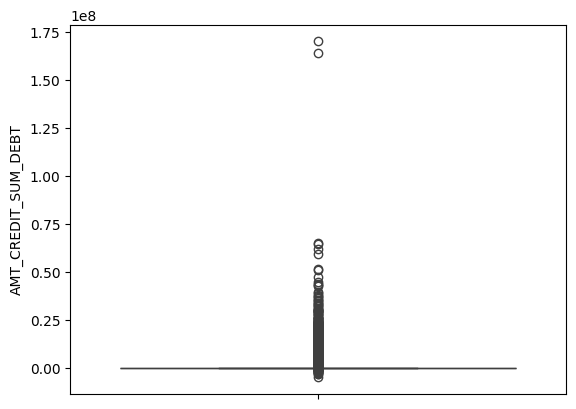

In [30]:
sns.boxplot(df['AMT_CREDIT_SUM_DEBT'])
plt.show()

In [31]:
df['AMT_CREDIT_SUM_LIMIT'].isnull().sum()

591780

- 34.47% values are missing. 

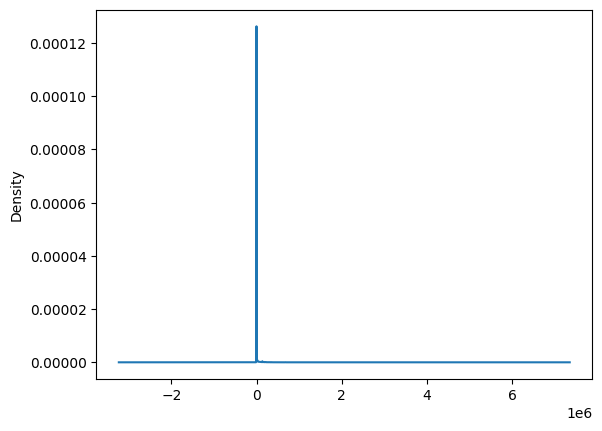

In [32]:
(df['AMT_CREDIT_SUM_LIMIT']).plot(kind='kde')
plt.show()

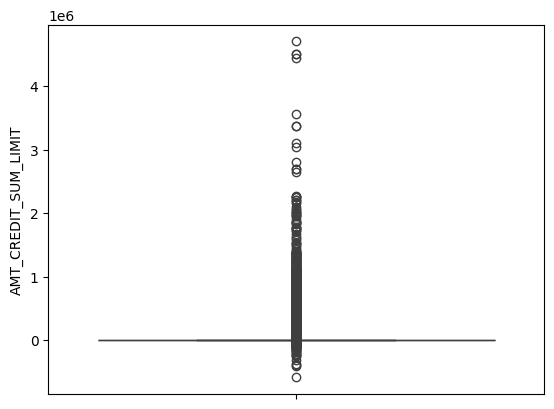

In [33]:
sns.boxplot(df['AMT_CREDIT_SUM_LIMIT'])
plt.show()

- This means at least 75% of all observations have a credit limit of zero.

In [34]:
df['AMT_ANNUITY'].isnull().sum()

1226791

- 71.47% missing values